In [4]:
import pandas as pd
data = {
    "Study_Hours": [2,3,4,5,6,7,8,3,5,6,4,7,2,8,5],
    "Attendance": [65,70,75,80,85,90,95,68,78,88,72,92,60,96,82],
    "Previous_Marks": [50,55,60,65,70,75,82,52,64,73,58,78,48,85,67],
    "Assignment_Score": [55,60,65,70,75,80,88,58,72,79,63,85,50,92,74],
    "Sleep_Hours": [6,7,7,8,8,7,8,6,7,8,6,8,6,9,7],
    "Final_Marks": [52,58,64,71,78,84,91,55,70,80,62,87,49,94,73]
}

df = pd.DataFrame(data)

df.head()
print("Rows and Columns:", df.shape)

df.info()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df[[
    "Study_Hours",
    "Attendance",
    "Previous_Marks",
    "Assignment_Score",
    "Sleep_Hours"
]]

# Target
y = df["Final_Marks"]

# Training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

print("Model trained successfully!")
print("Predictions:", predictions)

Rows and Columns: (15, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Study_Hours       15 non-null     int64
 1   Attendance        15 non-null     int64
 2   Previous_Marks    15 non-null     int64
 3   Assignment_Score  15 non-null     int64
 4   Sleep_Hours       15 non-null     int64
 5   Final_Marks       15 non-null     int64
dtypes: int64(6)
memory usage: 852.0 bytes
Model trained successfully!
Predictions: [80.22000991 86.35570274 51.37703526]


In [5]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Average Error:", error)

Average Error: 0.49575730265019047


In [6]:
new_student = [[6, 85, 70, 75, 8]]

prediction = model.predict(new_student)

print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: 77.52370772637336


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
marks = prediction[0]

if marks >= 80:
    performance = "Excellent"
elif marks >= 70:
    performance = "Good"
elif marks >= 60:
    performance = "Average"
else:
    performance = "Needs Improvement"

print("Predicted Marks:", round(marks, 2))
print("Performance:", performance)

Predicted Marks: 77.52
Performance: Good


In [8]:
if marks >= 80:
    risk = "Low Risk"
elif marks >= 60:
    risk = "Medium Risk"
else:
    risk = "High Risk"

print("Risk Level:", risk)

Risk Level: Medium Risk


In [9]:
if attendance < 75:
    suggestion = "Improve your attendance."
elif study_hours < 4:
    suggestion = "Try to increase your daily study hours."
elif assignment_score < 60:
    suggestion = "Focus more on completing assignments."
elif sleep_hours < 6:
    suggestion = "Try to get more sleep for better concentration."
else:
    suggestion = "Good job! Keep maintaining your current routine."

print("Suggestion:", suggestion)

NameError: name 'attendance' is not defined

In [10]:
# New student's information
study_hours = 6
attendance = 85
previous_marks = 70
assignment_score = 75
sleep_hours = 8

# Performance
marks = prediction[0]

if marks >= 80:
    performance = "Excellent"
elif marks >= 70:
    performance = "Good"
elif marks >= 60:
    performance = "Average"
else:
    performance = "Needs Improvement"

# Risk
if marks >= 80:
    risk = "Low Risk"
elif marks >= 60:
    risk = "Medium Risk"
else:
    risk = "High Risk"

# Suggestion
if attendance < 75:
    suggestion = "Improve your attendance."
elif study_hours < 4:
    suggestion = "Increase your daily study hours."
elif assignment_score < 60:
    suggestion = "Focus more on completing assignments."
elif sleep_hours < 6:
    suggestion = "Try to get more sleep."
else:
    suggestion = "Good job! Keep maintaining your current routine."

print("Predicted Marks:", round(marks, 2))
print("Performance:", performance)
print("Risk Level:", risk)
print("Suggestion:", suggestion)

Predicted Marks: 77.52
Performance: Good
Risk Level: Medium Risk
Suggestion: Good job! Keep maintaining your current routine.


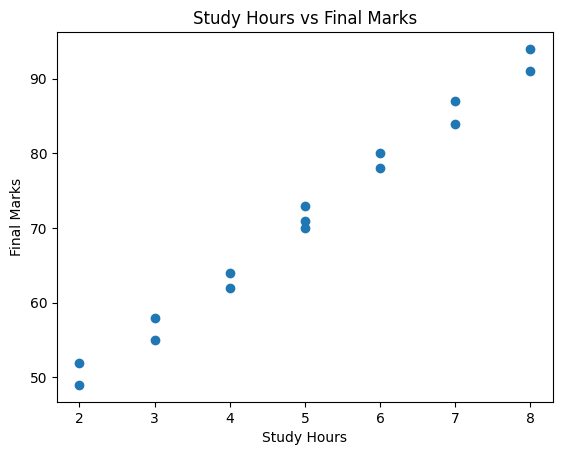

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

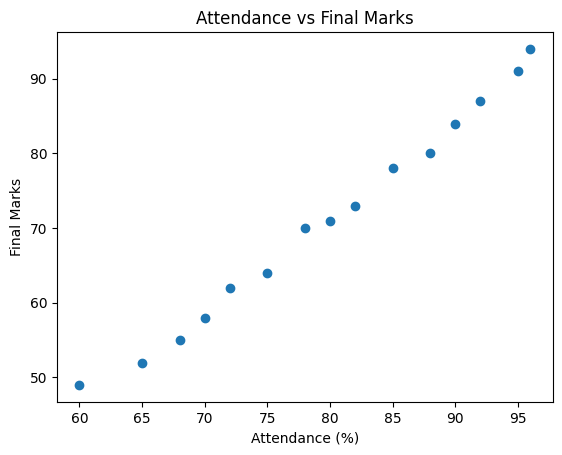

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df["Attendance"], df["Final_Marks"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.show()

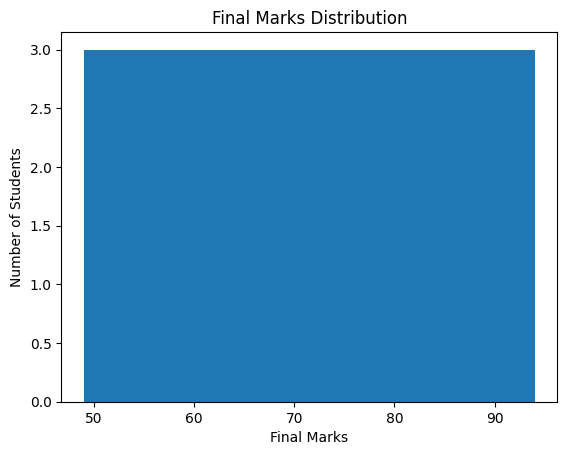

In [13]:
import matplotlib.pyplot as plt

plt.hist(df["Final_Marks"], bins=5)

plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.title("Final Marks Distribution")

plt.show()

In [14]:
import pickle

with open("student_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [24]:
!pip install Gradio
import gradio as gr

print(gr.__version__)

6.26.0


In [21]:

import gradio as gdr
print("Gradio is ready")

Gradio is ready


In [ ]:
study_hours = gr.Number(label="Study Hours")
attendance = gr.Number(label="Attendance (%)")
previous_marks = gr.Number(label="Previous Marks")
assignment_score = gr.Number(label="Assignment Score")
sleep_hours = gr.Number(label="Sleep Hours")

In [22]:
def predict_marks(study_hours, attendance, previous_marks, assignment_score, sleep_hours):

    new_student = [[
        study_hours,
        attendance,
        previous_marks,
        assignment_score,
        sleep_hours
    ]]

    prediction = model.predict(new_student)

    return round(prediction[0], 2)

In [19]:
result = predict_marks(6, 85, 70, 75, 8)

print("Predicted Marks:", result)

Predicted Marks: 77.52


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
import gradio as gr

interface = gr.Interface(
    fn=predict_marks,
    inputs=[
        gr.Number(label="Study Hours"),
        gr.Number(label="Attendance (%)"),
        gr.Number(label="Previous Marks"),
        gr.Number(label="Assignment Score"),
        gr.Number(label="Sleep Hours")
    ],
    outputs=gr.Number(label="Predicted Final Marks")
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://35275f11ce9d1f6935.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
def analyze_student(study_hours, attendance, previous_marks, assignment_score, sleep_hours):

    new_student = [[
        study_hours,
        attendance,
        previous_marks,
        assignment_score,
        sleep_hours
    ]]

    prediction = model.predict(new_student)
    marks = round(prediction[0], 2)

    if marks >= 80:
        performance = "Excellent"
        risk = "Low Risk"
    elif marks >= 70:
        performance = "Good"
        risk = "Medium Risk"
    elif marks >= 60:
        performance = "Average"
        risk = "Medium Risk"
    else:
        performance = "Needs Improvement"
        risk = "High Risk"

    if attendance < 75:
        suggestion = "Improve your attendance."
    elif study_hours < 4:
        suggestion = "Increase your daily study hours."
    elif assignment_score < 60:
        suggestion = "Focus more on assignments."
    elif sleep_hours < 6:
        suggestion = "Try to get more sleep."
    else:
        suggestion = "Good job! Keep maintaining your routine."

    return marks, performance, risk, suggestion

In [28]:
interface = gr.Interface(
    fn=analyze_student,

    inputs=[
        gr.Number(label="Study Hours"),
        gr.Number(label="Attendance (%)"),
        gr.Number(label="Previous Marks"),
        gr.Number(label="Assignment Score"),
        gr.Number(label="Sleep Hours")
    ],

    outputs=[
        gr.Number(label="Predicted Final Marks"),
        gr.Textbox(label="Performance"),
        gr.Textbox(label="Risk Level"),
        gr.Textbox(label="Suggestion")
    ],

    title="🎓 Student Performance & Risk Analyzer",
    description="Enter student information to analyze academic performance."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1ad85bc23b0649b886.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [29]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [37]:
import shutil

shutil.copy(
    "student_model.pkl",
    "/content/drive/MyDrive/student_model.pkl"
)

print("Model saved to Google Drive!")

Model saved to Google Drive!


In [31]:
import os

print(os.listdir())

['.config', '.gradio', 'student_model.pkl', 'sample_data']


In [36]:
import shutil

shutil.copy(
    "student_model.pkl",
    "/content/drive/MyDrive/student_model.pkl"
)

print("Model saved to Google Drive!")

Model saved to Google Drive!


In [35]:
import os

print(os.path.exists("/content/drive"))
print(os.path.exists("/content/drive/MyDrive"))

True
True


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
import gradio as gr

with gr.Blocks(title="Student Performance & Risk Analyzer") as interface:

    gr.Markdown(
        """
        # 🎓 Student Performance & Risk Analyzer

        Enter the student's academic information below to predict
        final marks, performance level, risk level, and get a personalized suggestion.
        """
    )

    gr.Markdown("### 📚 Student Information")

    with gr.Row():
        study_hours = gr.Number(
            label="Study Hours",
            minimum=0,
            maximum=24
        )

        attendance = gr.Number(
            label="Attendance (%)",
            minimum=0,
            maximum=100
        )

    with gr.Row():
        previous_marks = gr.Number(
            label="Previous Marks",
            minimum=0,
            maximum=100
        )

        assignment_score = gr.Number(
            label="Assignment Score",
            minimum=0,
            maximum=100
        )

    sleep_hours = gr.Number(
        label="Sleep Hours",
        minimum=0,
        maximum=24
    )

    analyze_button = gr.Button(
        "🔍 Analyze Student"
    )

    gr.Markdown("### 📊 Analysis Results")

    with gr.Row():
        predicted_marks = gr.Number(
            label="Predicted Final Marks"
        )

        performance = gr.Textbox(
            label="Performance"
        )

    with gr.Row():
        risk = gr.Textbox(
            label="Risk Level"
        )

        suggestion = gr.Textbox(
            label="Personalized Suggestion"
        )

    analyze_button.click(
        fn=analyze_student,
        inputs=[
            study_hours,
            attendance,
            previous_marks,
            assignment_score,
            sleep_hours
        ],
        outputs=[
            predicted_marks,
            performance,
            risk,
            suggestion
        ]
    )

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8bea209513c59769ea.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
